In [1]:
import numpy as np

import numpy.linalg as la

import matplotlib.pyplot as plt

import cv2

from PIL import Image

import pickle

import os

In [2]:
DATA_DIR = './cifar-10-batches-py'

# Load a single CIFAR-10 batch from disk
def load_batch(filepath):

    with open(filepath, 'rb') as f:

        d = pickle.load(f, encoding='bytes')

    images = d[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    labels = np.array(d[b'labels'])

    return images, labels

# Load human-readable class names from batches.meta
def load_class_names(meta_filepath):

    with open(meta_filepath, 'rb') as f:

        meta = pickle.load(f, encoding='bytes')

    class_names = [name.decode('utf-8') for name in meta[b'label_names']]

    return class_names

# Load all 5 training batches and concatenate
train_batches = [load_batch(os.path.join(DATA_DIR, f'data_batch_{i}')) for i in range(1, 6)]

train_images = np.concatenate([b[0] for b in train_batches])

train_labels = np.concatenate([b[1] for b in train_batches])

# Load test batch
test_images, test_labels = load_batch(os.path.join(DATA_DIR, 'test_batch'))

# Load class names
class_names = load_class_names(os.path.join(DATA_DIR, 'batches.meta'))

print(len(train_images), len(test_images), train_images[0].shape, class_names)

50000 10000 (32, 32, 3) ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
# Extract a 96-dim normalized color histogram from an RGB image
def extract_color_histogram(img_rgb):

    hist_r = np.histogram(img_rgb[:, :, 0], bins=32, range=(0, 256))[0]

    hist_g = np.histogram(img_rgb[:, :, 1], bins=32, range=(0, 256))[0]

    hist_b = np.histogram(img_rgb[:, :, 2], bins=32, range=(0, 256))[0]

    feat = np.concatenate([hist_r, hist_g, hist_b]).astype(np.float32)

    feat = feat / (feat.sum() + 1e-7)

    return feat

feat_test = extract_color_histogram(train_images[0])

assert feat_test.shape == (96,)

assert feat_test.dtype == np.float32

In [4]:
k = 10

N_QUERIES = 100

TOTAL_RELEVANT = 5000

db_features = np.zeros((len(train_images), 96), dtype=np.float32)

# Compute histogram feature for every training image
for i in range(len(train_images)):

    db_features[i] = extract_color_histogram(train_images[i])

    if i % 10000 == 0:

        print(f'Processed {i}/50000')

assert db_features.shape == (50000, 96)

print(db_features.shape, db_features.dtype)

Processed 0/50000
Processed 10000/50000
Processed 20000/50000
Processed 30000/50000
Processed 40000/50000
(50000, 96) float32


In [5]:
# Retrieve top-k nearest neighbours by L2 distance
def retrieve(query_vec, db_features, k=10):

    dists = la.norm(db_features - query_vec, axis=1)

    top_k_idx = np.argsort(dists)[:k]

    return top_k_idx, dists[top_k_idx]

# Smoke test retrieval
query_idx = 0

query_vec = db_features[0]

top_k_idx, top_k_dists = retrieve(query_vec, db_features, k=10)

assert len(top_k_idx) == 10

assert top_k_dists[0] <= top_k_dists[-1]

print(top_k_idx, top_k_dists)

[    0  3796 32344 10034 36720 34686 24663 37822  8839 42914] [0.         0.03512911 0.05150846 0.05544376 0.05560788 0.05781089
 0.05784387 0.05931808 0.05960144 0.06023807]


In [6]:
# Fraction of retrieved results matching the query label
def precision_at_k(query_label, retrieved_labels, k):

    count = np.sum(retrieved_labels[:k] == query_label)

    return count / k

# Fraction of all relevant items retrieved in top-k
def recall_at_k(query_label, retrieved_labels, k, total_relevant):

    count = np.sum(retrieved_labels[:k] == query_label)

    return count / total_relevant

# Reciprocal rank of the first correct result
def reciprocal_rank(query_label, retrieved_labels):

    for i, label in enumerate(retrieved_labels):

        if label == query_label:

            return 1.0 / (i + 1)

    return 0.0

np.random.seed(42)

query_indices = np.random.choice(len(test_images), size=N_QUERIES, replace=False)

precisions = []

recalls = []

rr_scores = []

for qi in query_indices:

    q_img = test_images[qi]

    q_label = test_labels[qi]

    q_feat = extract_color_histogram(q_img)

    top_k_idx, _ = retrieve(q_feat, db_features, k=k)

    retrieved_labels = train_labels[top_k_idx]

    precisions.append(precision_at_k(q_label, retrieved_labels, k))

    recalls.append(recall_at_k(q_label, retrieved_labels, k, TOTAL_RELEVANT))

    rr_scores.append(reciprocal_rank(q_label, retrieved_labels))

mean_precision = np.mean(precisions)

mean_recall = np.mean(recalls)

mrr = np.mean(rr_scores)

print(f'Color Histogram | P@{k}: {mean_precision:.3f} | R@{k}: {mean_recall:.3f} | MRR: {mrr:.3f}')

print('Descriptor | P@k | R@k | MRR')

print(f'Color Histogram | {mean_precision:.3f} | {mean_recall:.3f} | {mrr:.3f}')

Color Histogram | P@10: 0.222 | R@10: 0.000 | MRR: 0.409
Descriptor | P@k | R@k | MRR
Color Histogram | 0.222 | 0.000 | 0.409


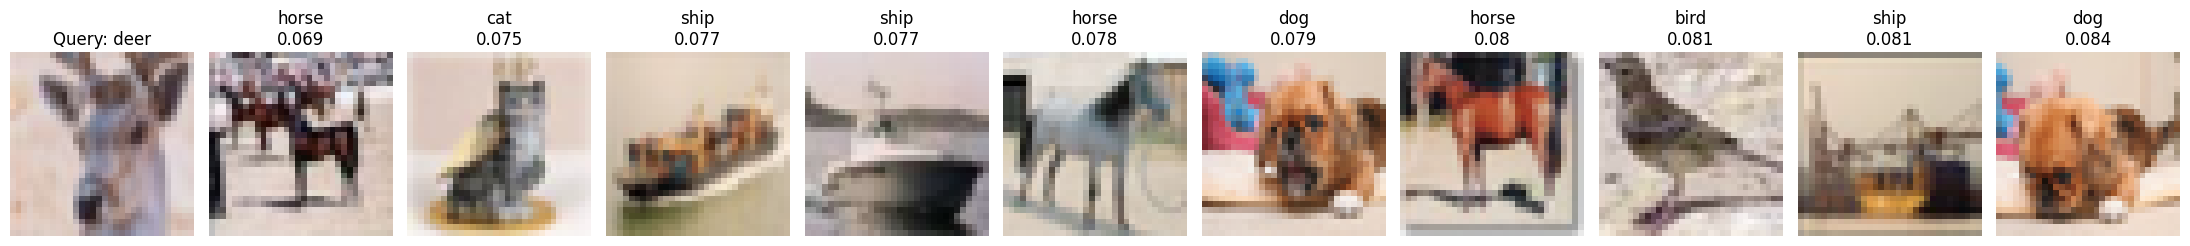

In [7]:
# Display query image and its top-k retrieved neighbours
def show_retrieval(query_img, query_label, top_k_imgs, top_k_labels, top_k_dists, class_names, k=10):

    fig, axes = plt.subplots(1, k + 1, figsize=(2 * (k + 1), 3))

    axes[0].imshow(query_img)

    axes[0].set_title('Query: ' + class_names[query_label])

    axes[0].axis('off')

    for j in range(k):

        axes[j + 1].imshow(top_k_imgs[j])

        axes[j + 1].set_title(class_names[top_k_labels[j]] + '\n' + str(round(top_k_dists[j], 3)))

        axes[j + 1].axis('off')

    plt.tight_layout()

    plt.show()

# Demo retrieval on a random test image
sample_idx = np.random.randint(len(test_images))

query_img = test_images[sample_idx]

query_label = test_labels[sample_idx]

query_feat = extract_color_histogram(query_img)

top_k_idx, top_k_dists = retrieve(query_feat, db_features, k=k)

top_k_imgs = train_images[top_k_idx]

top_k_labels = train_labels[top_k_idx]

show_retrieval(query_img, query_label, top_k_imgs, top_k_labels, top_k_dists, class_names, k=k)